# 4. Advanced - conditions and grouping models

In Tutorial 3 we have analyzed a dataset of 5 participants of a moving-dots experiment with two different conditions: a speed condition and an accuracy condition. We fitted an overall model, and then checked how the events and intervals between events depended on the condition. Especially the duration turned out to be very different. On the one hand, given these results, you might wonder whether it wouldn't be better to fit the conditions separately. On the other hand, most of the events seem very similar. In this tutorial we will explore how we can account for both these observation in a single, _grouped_ model.

We start by loading the data the same way as we did in tutorial 3:

In [1]:
import os
import hmp
import numpy as np

import matplotlib.pyplot as plt
import requests

# Declaring path where the EEG data will be stored
epoch_data_path = os.path.join('sample_data', 'eeg')
os.makedirs(epoch_data_path, exist_ok=True)

# URLs of the first 5 participants in the SAT experiment, navigate the osf folder and adapt those if you want to do this tutorial on other data (e.g. P3, N2pc). You can also change 5 to 25 to do the analysis on the full dataset.
base = "https://files.osf.io/v1/resources/29tgr/providers/github/results/replication/SAT_data/"
file_urls = [base + f"processed_500Hz_{(x+1):04d}_epo.fif" for x in range(5)]

# Download and save each file if not already in folder
for i, url in enumerate(file_urls, start=1):
    file_path = os.path.join(epoch_data_path, f'S{i}_epo.fif')
    if not os.path.exists(file_path):
        response = requests.get(url)
        with open(file_path, 'wb') as f:
            f.write(response.content)

# Recovering individual files and participant names
subj_files = [os.path.join(epoch_data_path, f) for f in os.listdir(epoch_data_path) if f.endswith('.fif')]  # Create a list of files with full paths

preprocessing = dict(sfreq=250) #Downsampling from 500Hz to 250Hz for speed and RAM usage
epoch_data, info = hmp.io.read_mne_epochs(subj_files,
                            montage='biosemi64',
                            preprocessing_kwargs=preprocessing,
                            verbose=False)#Turning verbose off for the documentation but it is recommended to leave it on as some output from MNE might be useful

## The following is just for this tutorial dataset and probably not needed for yours
# The duration (i.e. reaction time) data is in milliseconds and we want it in seconds
epoch_data['RT'] /= 1000
# This dataset is in microV, we want the unit in V
epoch_data *= 1e-6

base_data = hmp.basedata.default(
    epoch_data, # The data from the io module
    duration_id='RT', # What coordinate in our data contains the duration we want to model
    min_duration = 0.2, # What minimum response time (in second) is reasonable given the task (e.g. anticipation)
    # Minimum duration dictates the number of event that can fit in the data, see FAQ
    max_duration = 2, # same for maximum duration (e.g. distraction or bug), for speed mostly, also to filter clear outliers
    offsets=0.03, # Adding 30ms before centering event and after duration end to pad for the crosscorrelation, not included in the data afterwards
    # Apply a threshold, i.e. reject trial if the absolute value of an electrode exceeds that value
    reject_amplitude = 1e-4, #Here trials get rejected if an electrode exceeds 100microV, useful in the case of artifacts in the data
    n_comp = .99, # How many PCA component we want to compress the data into, here we take as many as necessary to achieve 99% of explained variance, the more the better
    whiten = True, #All components will have unit variance
    common_variance = True, # All trials will have the same standard deviation
    recording_zscore = True # Zscore the components per recording/participant so that all participant are represented equally by the PCs
)

pattern = hmp.patterns.HalfSine(width=50)
pattern_data = hmp.patterndata.PatternData.from_basedata(base_data, pattern=pattern)

Found 900 trials with positively defined durations and 20 trials without durations (0 or nan)

Rejection summary: 
 0 trials rejected based on threshold of 0.0001 
 1 trials rejected  based on duration limit of (0.2, 2) 
 0 with duration but without data (nan at time 0)
7 components retained, explaining 0.99342% variance


## Splitting conditions

When having estimated a model across all conditions, we can also split the resulting fit by condition. This is useful to see how the model estimates differ across conditions, such as speed vs accuracy instructions in this case. We already did this partly in the previous tutorial, but will now split the estimates themselves and make separate plots. First, we refit the model, now just using `EventModel` instead of the `CumulativeMethod`, as it is faster and we already know that we're looking for three events (and it does find the same solution in this case).

Estimating 3 events model


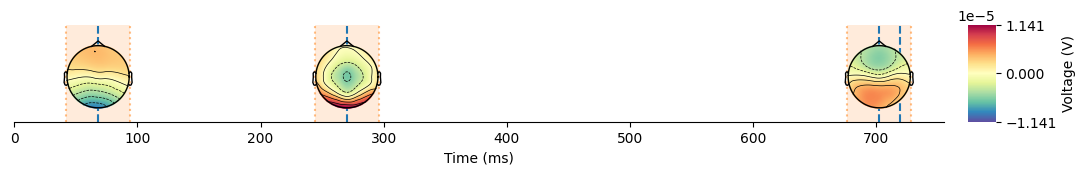

In [2]:
model_3ev = hmp.models.EventModel(n_events=3)
lkh_3ev, estimates_3ev = model_3ev.fit_transform(data=pattern_data)
hmp.visu.plot_model(epoch_data, estimates_3ev, info, as_time=True)

### Shared model

As a next step, we simply split the estimates and plot the results separately for 'Speed' and 'Accuracy'.

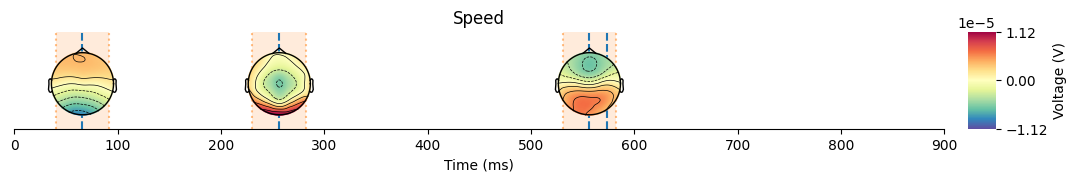

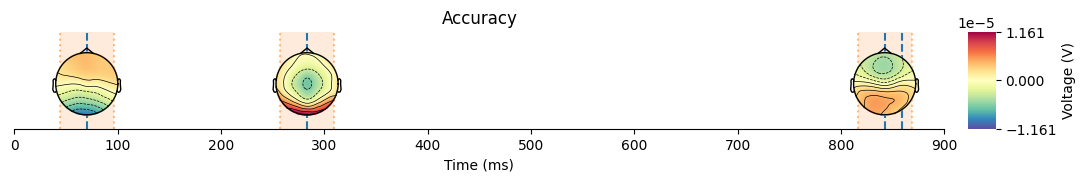

In [3]:
speed_estimates = hmp.utils.select_coord(estimates_3ev, 'SP', variable='cue')
accuracy_estimates =  hmp.utils.select_coord(estimates_3ev, 'AC', variable='cue')

hmp.visu.plot_topo_timecourse(epoch_data, speed_estimates, info, max_time=900, title='Speed')
hmp.visu.plot_topo_timecourse(epoch_data, accuracy_estimates, info, max_time=900, title='Accuracy')

This reflects the results of tutorial 3, with a much longer duration for the penultimate interval for the accuracy condition. However, given this large difference, one might wonder if we shouldn't fit different models altogether for these two conditions.

### Independent models

That is indeed the next step, we split the data in two and fit two separate models. We would like to do that using the Cumulative method to see how many events are found per condition. However, as that takes quite a lot of time, we also implemented standard Event models for 3 and 4 events, for speed and accuracy, respectively. These are the numbers that are found by the Cumulative method, and is also what we [reported before](https://direct.mit.edu/imag/article/doi/10.1162/imag_a_00400/125469/Trial-by-trial-detection-of-cognitive-events-in). If you'd like to use the Cumulative method, set `cumulative` to `True`.

Estimating 3 events model
Estimating 4 events model


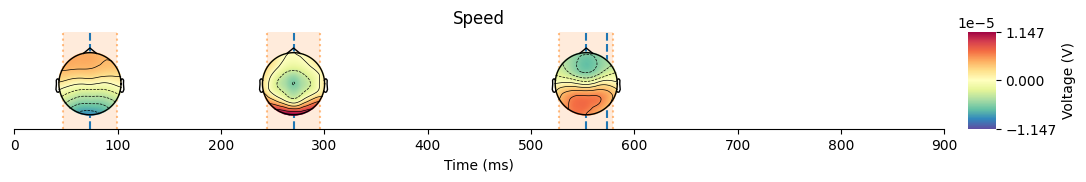

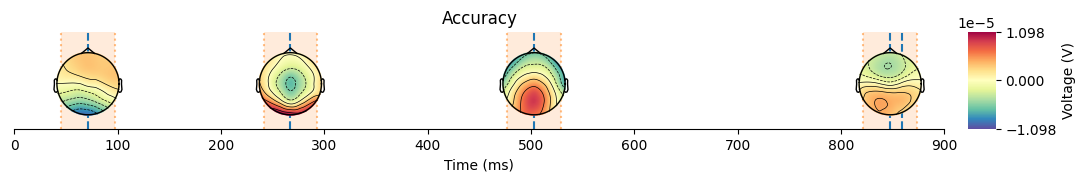

In [4]:
cumulative = False #set to true if you want to try the cumulative method, will take at least 4 minutes to run.

#select data
base_data_speed = base_data.select_coord(value='SP', variable='cue')
base_data_accuracy = base_data.select_coord(value='AC', variable='cue')

if cumulative:
    model_speed = hmp.models.CumulativeMethod(pattern=pattern)
    model_accuracy = hmp.models.CumulativeMethod(pattern=pattern)
else:
    model_speed = hmp.models.EventModel(n_events=3, pattern=pattern)
    model_accuracy = hmp.models.EventModel(n_events=4, pattern=pattern)

ll_cumulative_speed, estimates_speed = model_speed.fit_transform(base_data_speed)
ll_cumulative_accuracy, estimates_accuracy = model_accuracy.fit_transform(base_data_accuracy)

hmp.visu.plot_topo_timecourse(epoch_data, estimates_speed, info, title='Speed', max_time=900)
hmp.visu.plot_topo_timecourse(epoch_data, estimates_accuracy, info, title='Accuracy', max_time=900)

Here, the models are fully independent. In the accuracy condition, one extra event is found, while the first two and the last events seem highly similar. While this might be a better representation of the data (more on that in Tutorial 5), it does use many more parameters: 10 for each event (PCs), an extra event, and an extra interval. In the next section, we look at how we can combine these models using the _grouped_ approach.

## Group models

What we would really like to do is tell HMP that it should fit one extra event in the accuracy condition, which comes between the 2nd and 3rd events. The properties of the other events should be shared between the conditions, resulting in a strong reduction in the number of fitted parameters.

This is exactly what the grouped modeling approach let's you do. By defining so called 'maps', one can define which events should be shared, and whether some events/intervals should not appear in one of the conditions – we always reason from the condition with most events.

Here are the maps that we use to defined the combined model based on the fits that we've just seen:

In [5]:
grouping_dict = {'cue': ['SP', 'AC']}   # Define conditions
channel_map = np.array([[0, 0, -1, 0],  # Channel map: third event missing for speed (-1)
                        [0, 0, 0, 0]])
time_map = np.array([[0, 0, -1, 1, 0],  # Time map: third interval missing for speed (-1), 
                     [0, 0, 0, 0, 0]])  # while the fourth interval might have different parameters (different number than accuracy)

First, we tell the method which conditions there are, where the order is important (i.e. Speed is the first condition in our maps). 

Next, we define the channel map. Each row indicates a condition, each column an event. Here we want four events (the condition with the most events), where the third stage does not exist for speed, as indicated by the -1. We can also change the numbers: if different rows have different numbers, the topologies are allowed to be varied between conditions. However, in this case we want to share the topologies, so all numbers are left at 0.

For the time map, we have five columns, representing the five intervals. We defined the third interval to not exist for the speed condition, but we also gave the fourth interval a different number (1) to allow this _third_ interval for speed to have a different duration. 

As these maps are somewhat hard to read, the fit method will give a summary of what is happening. Now, we can just include those three items in an `EventModel`. Note that `n_events` still needs to be provided.

group "cue" analyzed, with groups: ['SP', 'AC']

Coded as follows: 
0: ['SP']
1: ['AC']

Channel map:
0:  [ 0  0 -1  0]
1:  [0 0 0 0]

Time map:
0:  [ 0  0 -1  1  0]
1:  [0 0 0 0 0]
Estimating 4 events model


/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=119354) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


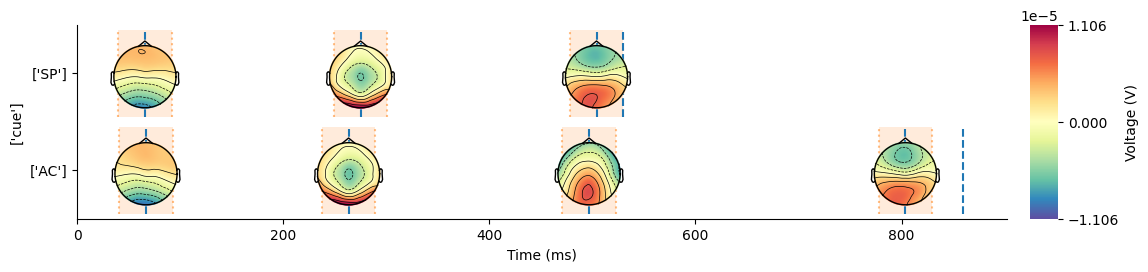

In [6]:
cpus=2 #set higher if you have the possibility

model_group = hmp.models.EventModel(n_events = 4, pattern=pattern, channel_map = channel_map, time_map = time_map, grouping_dict = grouping_dict)

lkhs, estimates_group = model_group.fit_transform(pattern_data, cpus=cpus)
hmp.visu.plot_model(epoch_data, estimates_group, info, as_time=True)

Here we found a very similar model as the ones above, but now with fewer parameters. What is more, we can compare their likelihoods by summing the likelihoods of the two independent models:

In [7]:
print('Likelihood independent models: ', ll_cumulative_speed + ll_cumulative_accuracy)
print('Likelihood grouped model: ', lkhs.sum())

Likelihood independent models:  -3826.3342
Likelihood grouped model:  -4366.8423


It seems like the use of fewer parameters has resulted in a less good fit. Note that the loglikelihoods can vary quite a bit due to the small datasets – sometimes the grouped model even outperforms the independent models.

### Multiple conditions

While this is already a nice result, we can take the approach one step further. We also know that participants gave their responses with their right and left hands (for dots moving to the right or to the left). Given that the last event is probably motor related, the EEG topology should be lateralized, as we have already seen in Tutorial 3. We can now fit the same model as we just did, but also make a distinction between left and right responses:

In [8]:
# Define conditions: 2x2, first item is changed slowest
grouping_dict = {'cue': ['SP', 'AC'], 
                 'resp': ['resp_right', 'resp_left']}  

channel_map = np.array([[0, 0, -1, 0],    # third event missing for speed
                        [0, 0, -1, 1],    # last event is different for right and left responses
                        [0, 0, 0, 0],
                        [0, 0, 0, 1]])
                        
time_map = np.array([[0, 0, -1, 0, 0],    # as before, one interval missing, one allowed to differ 
                     [0, 0, -1, 0, 0],    # between speed and accuracy
                     [0, 0, 0, 1, 0],
                     [0, 0, 0, 1, 0]])

Again, we indicated the differences in events and intervals, but now we added left- and right-handed responses. As the first defined condition changes slowest, the first two rows indicate speed, the last two accuracy. Again, check the summary given by the fit method below to make sure that the maps are correct.

In this case, we let the final event vary by condition, but only by hand, as we don't expect it to be different for all four conditions (in which case we would have used 0-3).

group "cue" analyzed, with groups: ['SP', 'AC']
group "resp" analyzed, with groups: ['resp_right', 'resp_left']

Coded as follows: 
0: ['SP' 'resp_right']
1: ['SP' 'resp_left']
2: ['AC' 'resp_right']
3: ['AC' 'resp_left']

Channel map:
0:  [ 0  0 -1  0]
1:  [ 0  0 -1  1]
2:  [0 0 0 0]
3:  [0 0 0 1]

Time map:
0:  [ 0  0 -1  0  0]
1:  [ 0  0 -1  0  0]
2:  [0 0 0 1 0]
3:  [0 0 0 1 0]
Estimating 4 events model


/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=119354) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


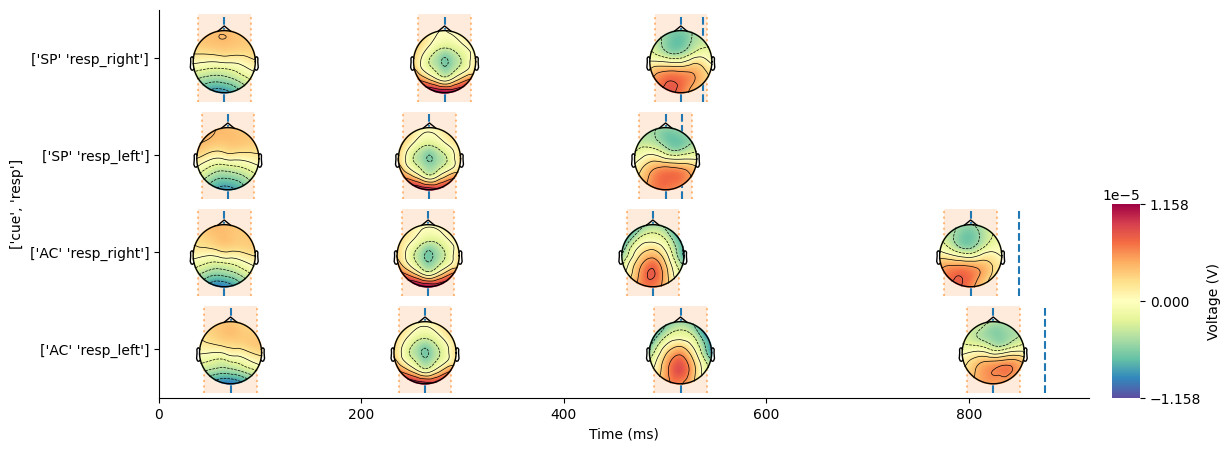

In [9]:
model_group = hmp.models.EventModel(n_events=4, pattern=pattern, channel_map=channel_map, time_map=time_map, grouping_dict=grouping_dict)
ll_group, estimates_group_uninformed = model_group.fit_transform(pattern_data, cpus=cpus)

hmp.visu.plot_model(epoch_data, estimates_group_uninformed, info, as_time=True)

This worked beautifully: 3 events in both speed conditions, while the last event is lateralized for right and left responses. If we now look at the likelihood, we observe the following:

In [10]:
print('Likelihood two conditions: ', lkhs.sum())
print('Likelihood four conditions: ', ll_group.sum()) 

Likelihood two conditions:  -4366.8423
Likelihood four conditions:  -4312.6553


... the model with the four conditions is better than the previous model with only two conditions, as it takes into account the different possibilities for the last event. Also here, the likelihood can vary considerably due to the small amount of data.